In [75]:
# Scrape the Olympics PDF

import pandas as pd
import numpy as np
import pdfplumber
import re

In [76]:
# Women's Free Skate:
def parse_protocol(pdf_path):

    text = ""

    with pdfplumber.open(pdf_path) as pdf:
        for page in pdf.pages:
            page_text = page.extract_text()
            if page_text:
                text += page_text + "\n"

    lines = text.split("\n")

    all_elements = []
    pcs_rows = []

    current_skater = None
    in_elements = False
    in_pcs = False

    for line in lines:

        line = line.strip()

        # ----------------------------
        # Detect skater header
        # Example: 1 LIU Alysa USA 22
        # ----------------------------
        skater_match = re.match(r"\d+\s+([A-Z][A-Za-z\-\']+\s+[A-Z][A-Za-z\-\']+)\s+[A-Z]{3}", line)
        if skater_match:
            current_skater = skater_match.group(1)
            in_elements = False
            in_pcs = False
            continue

        # ----------------------------
        # Detect sections
        # ----------------------------
        if "# Executed Elements" in line:
            in_elements = True
            in_pcs = False
            continue

        if "Program Components" in line:
            in_elements = False
            in_pcs = True
            continue

        # ============================
        # ELEMENT PARSING (token based)
        # ============================
        if in_elements and re.match(r"^\d+\s", line):

            tokens = line.split()

            try:
                element_number = int(tokens[0])
                element_code = tokens[1]

                # base value always next numeric
                base_val = float(tokens[2])

                idx = 3

                # handle second half bonus
                if tokens[idx] == "x":
                    idx += 1

                goe = float(tokens[idx])

                final_score = float(tokens[-1])

                all_elements.append({
                    "Skater": current_skater,
                    "Element #": element_number,
                    "Element": element_code,
                    "Base Value": base_val,
                    "GOE": goe,
                    "Final Score": final_score
                })

            except:
                pass

        # ============================
        # PCS PARSING
        # ============================
        if in_pcs:

            pcs_match = re.match(
                r"(Composition|Presentation|Skating Skills)\s+([\d\.]+)\s+(.+)",
                line
            )

            if pcs_match:

                component = pcs_match.group(1)
                factor = float(pcs_match.group(2))

                nums = [float(x) for x in pcs_match.group(3).split()]

                judge_scores = nums[:-1]
                panel_avg = nums[-1]

                for j, score in enumerate(judge_scores):
                    pcs_rows.append({
                        "Skater": current_skater,
                        "Component": component,
                        "Judge": f"J{j+1}",
                        "Score": score,
                        "Factor": factor,
                        "Panel Avg": panel_avg
                    })

    elements_df = pd.DataFrame(all_elements)
    pcs_df = pd.DataFrame(pcs_rows)

    return elements_df, pcs_df

elements_df, pcs_df = parse_protocol("2026Olympics_WomenFS.pdf")

pcs_wide = pcs_df.pivot_table(index=['Skater', 'Component'],columns='Judge',values='Score',sort = False)
panel_avg = pcs_df.groupby(['Skater', 'Component'])['Panel Avg'].first()
pcs_wide = pcs_wide.assign(Panel_Avg=panel_avg)
elements_wide = elements_df.pivot_table(index=['Skater','Element #','Element'],values=['Base Value','GOE','Final Score'])

# Turning them into csv files:
pcs_wide = pcs_wide.assign(Panel_Avg=panel_avg)
pcs_wide = pcs_wide.reset_index()
pcs_wide.to_csv("2026Olympics_WomenFS_PCS.csv", index=False)

elements_wide = elements_df.pivot_table(
    index=['Skater', 'Element #', 'Element'],
    values=['Base Value', 'GOE', 'Final Score']
)

elements_wide = elements_wide.reset_index()

elements_wide.to_csv("2026Olympics_WomenFS_Elements.csv", index=False)

In [77]:
# Men's Free Skate:
def parse_protocol(pdf_path):

    text = ""

    with pdfplumber.open(pdf_path) as pdf:
        for page in pdf.pages:
            page_text = page.extract_text()
            if page_text:
                text += page_text + "\n"

    lines = text.split("\n")

    all_elements = []
    pcs_rows = []

    current_skater = None
    in_elements = False
    in_pcs = False

    for line in lines:

        line = line.strip()

        # ----------------------------
        # Detect skater header
        # Example: 1 LIU Alysa USA 22
        # ----------------------------
        skater_match = re.match(r"\d+\s+([A-Z][A-Za-z\-\']+\s+[A-Z][A-Za-z\-\']+)\s+[A-Z]{3}", line)
        if skater_match:
            current_skater = skater_match.group(1)
            in_elements = False
            in_pcs = False
            continue

        # ----------------------------
        # Detect sections
        # ----------------------------
        if "# Executed Elements" in line:
            in_elements = True
            in_pcs = False
            continue

        if "Program Components" in line:
            in_elements = False
            in_pcs = True
            continue

        # ============================
        # ELEMENT PARSING (token based)
        # ============================
        if in_elements and re.match(r"^\d+\s", line):

            tokens = line.split()

            try:
                element_number = int(tokens[0])
                element_code = tokens[1]

                # base value always next numeric
                base_val = float(tokens[2])

                idx = 3

                # handle second half bonus
                if tokens[idx] == "x":
                    idx += 1

                goe = float(tokens[idx])

                final_score = float(tokens[-1])

                all_elements.append({
                    "Skater": current_skater,
                    "Element #": element_number,
                    "Element": element_code,
                    "Base Value": base_val,
                    "GOE": goe,
                    "Final Score": final_score
                })

            except:
                pass

        # ============================
        # PCS PARSING
        # ============================
        if in_pcs:

            pcs_match = re.match(
                r"(Composition|Presentation|Skating Skills)\s+([\d\.]+)\s+(.+)",
                line
            )

            if pcs_match:

                component = pcs_match.group(1)
                factor = float(pcs_match.group(2))

                nums = [float(x) for x in pcs_match.group(3).split()]

                judge_scores = nums[:-1]
                panel_avg = nums[-1]

                for j, score in enumerate(judge_scores):
                    pcs_rows.append({
                        "Skater": current_skater,
                        "Component": component,
                        "Judge": f"J{j+1}",
                        "Score": score,
                        "Factor": factor,
                        "Panel Avg": panel_avg
                    })

    elements_df = pd.DataFrame(all_elements)
    pcs_df = pd.DataFrame(pcs_rows)

    return elements_df, pcs_df

elements_df, pcs_df = parse_protocol("2026Olympics_MenFS.pdf")

pcs_wide = pcs_df.pivot_table(index=['Skater', 'Component'],columns='Judge',values='Score',sort = False)
panel_avg = pcs_df.groupby(['Skater', 'Component'])['Panel Avg'].first()
pcs_wide = pcs_wide.assign(Panel_Avg=panel_avg)
elements_wide = elements_df.pivot_table(index=['Skater','Element #','Element'],values=['Base Value','GOE','Final Score'])

# Turning them into csv files:
pcs_wide = pcs_wide.assign(Panel_Avg=panel_avg)
pcs_wide = pcs_wide.reset_index()
pcs_wide.to_csv("2026Olympics_MenFS_PCS.csv", index=False)

elements_wide = elements_df.pivot_table(
    index=['Skater', 'Element #', 'Element'],
    values=['Base Value', 'GOE', 'Final Score']
)

elements_wide = elements_wide.reset_index()

elements_wide.to_csv("2026Olympics_MenFS_Elements.csv", index=False)

In [78]:
# Train Data:
elements_data_train = pd.read_csv('all_elements.csv')
pcs_data_train = pd.read_csv('all_pcs.csv')

elements_data_train = elements_data_train.drop(columns = 'Unnamed: 0')
pcs_data_train = pcs_data_train.drop(columns = 'Unnamed: 0')

# Test Data:
elements_data_men = pd.read_csv("2026Olympics_MenFS_Elements.csv")
pcs_data_men = pd.read_csv("2026Olympics_MenFS_PCS.csv")

elements_data_women = pd.read_csv("2026Olympics_WomenFS_Elements.csv")
pcs_data_women = pd.read_csv("2026Olympics_WomenFS_PCS.csv")

In [79]:
elements_data_men['Gender'] = 'Men'

elements_data_women['Gender'] = 'Women'

In [80]:
elements_data_test = pd.concat([elements_data_men,elements_data_women],axis = 0)

In [81]:
elements_data_test

,Skater,Element #,Element,Base Value,Final Score,GOE,Gender
0,AYMOZ Kevin,1,3T,4.20,4.020,-0.180,Men
1,AYMOZ Kevin,2,4T,9.50,8.415,-1.085,Men
2,AYMOZ Kevin,3,3A+2A+SEQ,11.30,13.360,2.060,Men
3,AYMOZ Kevin,3,4T+3T,13.70,15.740,2.040,Men
4,AYMOZ Kevin,4,3Lo,4.90,4.410,-0.490,Men
...,...,...,...,...,...,...,...
240,ZHANG Ruiyang,8,3S,4.73,5.410,0.680,Women
241,ZHANG Ruiyang,9,2A+1Eu+2F,6.16,6.300,0.140,Women
242,ZHANG Ruiyang,10,CCoSp4,3.50,4.200,0.700,Women
243,ZHANG Ruiyang,11,StSq4,3.90,4.900,1.000,Women


In [82]:
pcs_data_men['Gender'] = 'Men'

pcs_data_women['Gender'] = 'Women'

pcs_data_test = pd.concat([pcs_data_men,pcs_data_women],axis = 0)

pcs_data_test

,Skater,Component,J1,J2,J3,J4,J5,J6,J7,J8,J9,Panel_Avg,Gender
0,SHAIDOROV Mikhail,Composition,8.25,8.00,8.50,8.00,8.50,8.75,8.25,8.75,8.00,8.32,Men
1,SHAIDOROV Mikhail,Presentation,8.50,8.50,8.25,8.00,8.75,8.50,8.25,8.50,8.25,8.39,Men
2,SHAIDOROV Mikhail,Skating Skills,8.50,8.75,8.50,8.25,8.75,8.50,8.00,8.25,8.75,8.50,Men
3,GOGOLEV Stephen,Composition,8.50,8.25,7.25,8.25,8.50,8.25,8.50,8.25,8.75,8.36,Men
4,GOGOLEV Stephen,Presentation,8.25,8.50,7.50,8.25,9.00,8.00,8.25,7.75,8.75,8.25,Men
...,...,...,...,...,...,...,...,...,...,...,...,...,...
64,REPOND Kimmy,Presentation,6.50,6.75,5.25,6.50,6.25,6.00,5.50,6.75,6.75,6.32,Women
65,REPOND Kimmy,Skating Skills,7.25,6.25,6.25,7.00,6.75,7.00,6.25,7.25,7.00,6.79,Women
66,SENIUK Mariia,Composition,6.50,6.00,6.50,6.50,6.25,5.75,6.25,6.75,6.00,6.29,Women
67,SENIUK Mariia,Presentation,7.00,5.75,6.25,6.25,5.75,5.00,6.00,6.75,5.75,6.07,Women


### Building the Regression Model:

In [83]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split

#### GOE Prediction

In [84]:
df = elements_data_train.copy()

df["is_jump"] = df["Element"].str.contains("A|Lz|F|Lo|S|T")
df["is_combo"] = df["Element"].str.contains("\+")
df["late_program"] = df["Element #"] >= 8 # elements performed later in the program may be awarded bonuses

df["skater_goe_mean"] = df.groupby("Skater")["GOE"].transform("mean")
df["skater_score_mean"] = df.groupby("Skater")["Final Score"].transform("mean")


X_goe = df[[
    "Base Value",
    "Element #",
    "is_jump",
    "is_combo",
    "late_program",
    "skater_goe_mean"
]]

y_goe = df["GOE"]

Xg_train, Xg_val, yg_train, yg_val = train_test_split(
    X_goe, y_goe, test_size=0.2, random_state=42
)

model1 = LinearRegression()
model1.fit(Xg_train, yg_train)

LinearRegression()

In [85]:
from sklearn.metrics import mean_squared_error
import numpy as np

pred_goe = model1.predict(Xg_val)
print("GOE RMSE:", np.sqrt(mean_squared_error(yg_val, pred_goe)))

GOE RMSE: 0.5863048544650519


#### Element Score prediction

In [86]:
# Step 1 — Define features WITHOUT actual GOE
X_score = df[[
    "Base Value",
    "Element #",
    "is_jump",
    "is_combo",
    "late_program",
    "skater_score_mean"
]]

# Target = Final Score minus Base Value
y_score = df["Final Score"] - df["Base Value"]

# Step 2 — Train/validation split
Xs_train, Xs_val, ys_train, ys_val = train_test_split(
    X_score, y_score, test_size=0.2, random_state=42
)

score_model = LinearRegression()
score_model.fit(Xs_train, ys_train)

pred_score = score_model.predict(Xs_val) + Xs_val["Base Value"]  # add base value back
print("Score RMSE:", np.sqrt(mean_squared_error(ys_val + Xs_val["Base Value"], pred_score)))

Score RMSE: 0.609680405691794


#### Test

In [87]:
df2 = elements_data_test.copy()

df2["is_jump"] = df2["Element"].str.contains("A|Lz|F|Lo|S|T")
df2["is_combo"] = df2["Element"].str.contains("\+")
df2["late_program"] = df2["Element #"] >= 8 # elements performed later in the program may be awarded bonuses

df2["skater_goe_mean"] = df2.groupby("Skater")["GOE"].transform("mean")
df2["skater_score_mean"] = df2.groupby("Skater")["Final Score"].transform("mean")

In [88]:
X_test_goe = df2[[
    "Base Value",
    "Element #",
    "is_jump",
    "is_combo",
    "late_program",
    "skater_goe_mean"
]]

df2["pred_goe"] = model1.predict(X_test_goe)

In [89]:
X_test_score = df2[[
    "Base Value",
    "Element #",
    "is_jump",
    "is_combo",
    "late_program",
    "skater_score_mean"
]]

# Step 2 — Predict execution bonus
df2["pred_score_bonus"] = score_model.predict(X_test_score)

# Step 3 — Add Base Value back to get full predicted element score
df2["pred_score"] = df2["Base Value"] + df2["pred_score_bonus"]

# Optional: drop temporary bonus column
df2.drop(columns="pred_score_bonus", inplace=True)

In [90]:
pred_tes = df2["pred_score"].sum()
actual_tes = df2["Final Score"].sum()

print("Predicted TES:", pred_tes)
print("Actual TES:", actual_tes)

Predicted TES: 3146.805927879038
Actual TES: 3075.705


In [91]:
df2[df2['Skater'] == 'MALININ Ilia']

,Skater,Element #,Element,Base Value,Final Score,GOE,Gender,is_jump,is_combo,late_program,skater_goe_mean,skater_score_mean,pred_goe,pred_score
127,MALININ Ilia,1,4F,11.00,15.71,4.71,Men,True,False,False,1.539,7.272,1.755463,12.205309
128,MALININ Ilia,2,1A,1.10,1.04,-0.06,Men,True,False,False,1.539,7.272,1.405274,2.132412
129,MALININ Ilia,3,4Lz,11.50,15.61,4.11,Men,True,False,False,1.539,7.272,1.773268,12.685318
130,MALININ Ilia,4,2Lo,1.70,1.77,0.07,Men,True,False,False,1.539,7.272,1.426617,2.714026
131,MALININ Ilia,5,CCSp3,2.80,3.44,0.64,Men,True,False,False,1.539,7.272,1.465591,3.817672
132,MALININ Ilia,6,StSq3,3.30,4.20,0.90,Men,True,False,False,1.539,7.272,1.483338,4.311689
133,MALININ Ilia,8,4T+1Eu+3F,16.83,19.54,2.71,Men,True,True,True,1.539,7.272,2.307918,18.456285
134,MALININ Ilia,10,ChSq1,3.00,4.36,1.36,Men,True,False,True,1.539,7.272,1.589957,4.155237
135,MALININ Ilia,11,FSSp3,2.60,2.90,0.30,Men,True,False,True,1.539,7.272,1.575863,3.734810
136,MALININ Ilia,12,CCoSp4,3.50,4.15,0.65,Men,True,False,True,1.539,7.272,1.607762,4.635247


#### Visualization

In [98]:
skater_summary = df2.groupby("Skater").agg(
    Gender=("Gender", "first"),   # ⭐ add this
    actual_TES=("Final Score", "sum"),
    predicted_TES=("pred_score", "sum"),
    avg_element_score=("Final Score", "mean"),
    avg_pred_element=("pred_score", "mean"),
    n_elements=("Element #", "count")
).reset_index()

# Performance difference
skater_summary["TES_diff"] = (
    skater_summary["predicted_TES"]
    - skater_summary["actual_TES"]
)

In [99]:
average_TES = df2.groupby("Element").agg(
    avg_base=("Base Value", "mean"),
    avg_score=("Final Score", "mean")
).reset_index()


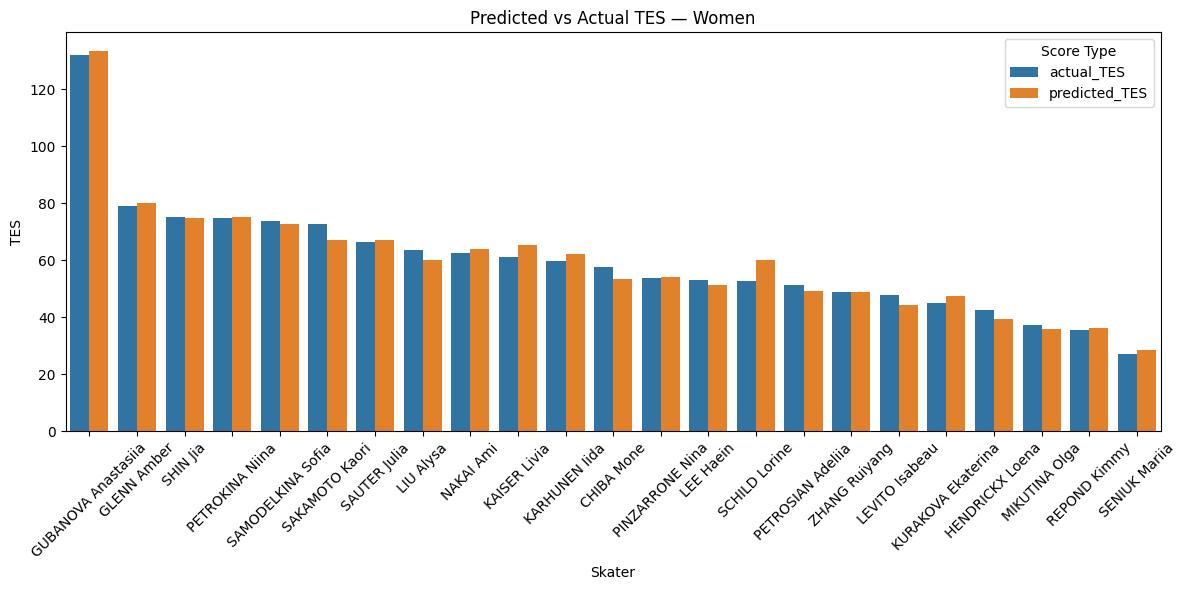

In [103]:
plt.figure(figsize=(12,6))

women_summary = (
    skater_summary[skater_summary["Gender"] == "Women"]
    .sort_values("actual_TES", ascending=False)
)

plot_df = women_summary.melt(
    id_vars="Skater",
    value_vars=["actual_TES","predicted_TES"],
    var_name="Score Type",
    value_name="TES"
)

sns.barplot(
    data=plot_df,
    x="Skater",
    y="TES",
    hue="Score Type",
    order=women_summary["Skater"]
)

plt.title("Predicted vs Actual TES — Women")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

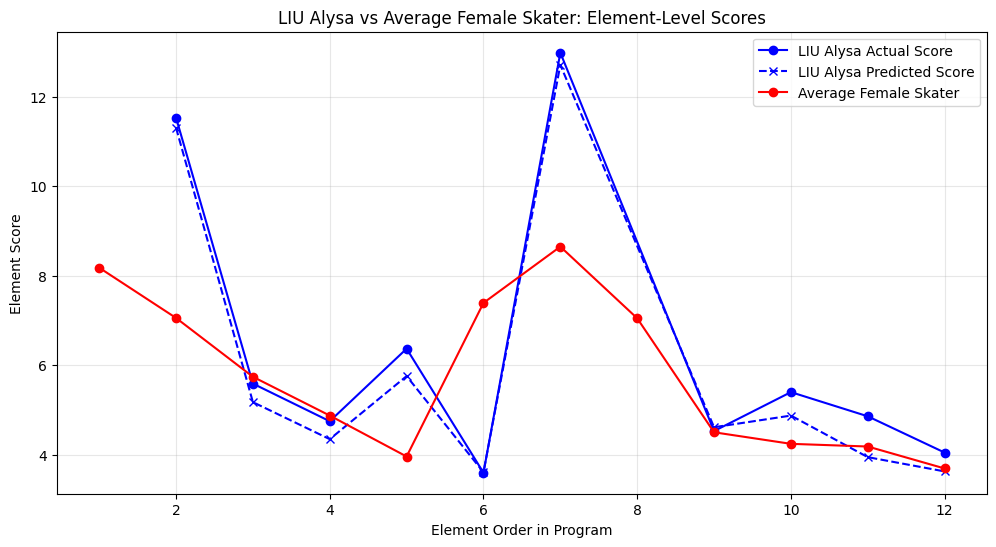

In [96]:

df2["Element #"] = df2["Element #"].astype(int)  # ensure consistent type

# --- Step 1: Set superstar ---
superstar = "LIU Alysa"

# --- Step 2: Extract Alysa's data ---
df_superstar = df2[df2["Skater"] == superstar]

if df_superstar.empty:
    raise ValueError(f"No data found for {superstar}! Check spelling and capitalization.")
    
# --- Step 3: Compute average female skater scores excluding Alysa ---
df_avg = (
    df2[(df2["Gender"] == "Women") & (df2["Skater"] != superstar)]
    .groupby("Element #")
    .agg(avg_score=("Final Score", "mean"))
    .reset_index()
)

# --- Step 4: Plot element-level scores ---
plt.figure(figsize=(12,6))

# Alysa actual scores
plt.plot(
    df_superstar["Element #"],
    df_superstar["Final Score"],
    marker='o',
    linestyle='-',
    color='blue',
    label=f"{superstar} Actual Score"
)

# Alysa predicted scores
plt.plot(
    df_superstar["Element #"],
    df_superstar["pred_score"],
    marker='x',
    linestyle='--',
    color='blue',
    label=f"{superstar} Predicted Score"
)

# Average female skater scores
plt.plot(
    df_avg["Element #"],
    df_avg["avg_score"],
    marker='o',
    linestyle='-',
    color='red',
    label="Average Female Skater"
)

# Labels and styling
plt.xlabel("Element Order in Program")
plt.ylabel("Element Score")
plt.title(f"{superstar} vs Average Female Skater: Element-Level Scores")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

In [ ]:
df2[df2['Skater']=='Alysa LIU']